# LeetCode #463: Island Perimeter

https://leetcode.com/problems/island-perimeter/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | O(m·n) | O(1) |
| **Single Pass (Count + Shared Edges)** | O(m·n) | O(1) |

---

## Understanding the Methods

### Brute Force
For each land cell, check all 4 neighbors: add 1 to the perimeter for each neighbor that is water or out-of-bounds. Correct but requires 4 conditional checks per land cell.

### Optimal: Single Pass (Count + Shared Edges) ★
Count all land cells (each contributes 4 edges) then subtract 2 for every shared edge between horizontally or vertically adjacent land cells. One pass, two simple counters, no directional branching.

**Why this is better than Brute Force:** Both are O(m·n) time and O(1) space, but Single Pass uses half the comparisons — it only looks right and down for shared edges rather than all 4 directions, and avoids the branching logic of boundary checks.

**Constraints:**
* row == grid.length, col == grid[i].length
* 1 ≤ row, col ≤ 100
* grid[i][j] is 0 or 1
* The grid contains exactly one island (no lakes inside)

## Solutions
### C#

In [ ]:
public class Solution {
    public int IslandPerimeter(int[][] grid) {
        int cells = 0, shared = 0;
        for (int r = 0; r < grid.Length; r++) {
            for (int c = 0; c < grid[0].Length; c++) {
                if (grid[r][c] == 0) continue;
                cells++;
                // Count right and down neighbors to find shared edges (each counted once)
                if (r + 1 < grid.Length    && grid[r+1][c] == 1) shared++;
                if (c + 1 < grid[0].Length && grid[r][c+1] == 1) shared++;
            }
        }
        return cells * 4 - shared * 2;
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def islandPerimeter(self, grid: List[List[int]]) -> int:
        cells = shared = 0
        rows, cols = len(grid), len(grid[0])
        for r in range(rows):
            for c in range(cols):
                if grid[r][c] == 0:
                    continue
                cells += 1
                # Count right and down neighbors to find shared edges (each counted once)
                if r + 1 < rows and grid[r+1][c] == 1:
                    shared += 1
                if c + 1 < cols and grid[r][c+1] == 1:
                    shared += 1
        return cells * 4 - shared * 2

### Go

In [ ]:
package main

func islandPerimeter(grid [][]int) int {
	cells, shared := 0, 0
	rows, cols := len(grid), len(grid[0])
	for r := 0; r < rows; r++ {
		for c := 0; c < cols; c++ {
			if grid[r][c] == 0 {
				continue
			}
			cells++
			// Count right and down neighbors to find shared edges (each counted once)
			if r+1 < rows && grid[r+1][c] == 1 {
				shared++
			}
			if c+1 < cols && grid[r][c+1] == 1 {
				shared++
			}
		}
	}
	return cells*4 - shared*2
}

### Rust

In [ ]:
impl Solution {
    pub fn island_perimeter(grid: Vec<Vec<i32>>) -> i32 {
        let (rows, cols) = (grid.len(), grid[0].len());
        let (mut cells, mut shared) = (0i32, 0i32);
        for r in 0..rows {
            for c in 0..cols {
                if grid[r][c] == 0 { continue; }
                cells += 1;
                // Count right and down neighbors to find shared edges (each counted once)
                if r + 1 < rows && grid[r+1][c] == 1 { shared += 1; }
                if c + 1 < cols && grid[r][c+1] == 1 { shared += 1; }
            }
        }
        cells * 4 - shared * 2
    }
}

## Example Scenarios

**1. Common Case — 4×4 grid with a simple island**

**Input:**
```
grid = [[0,1,0,0],
        [1,1,1,0],
        [0,1,0,0],
        [1,1,0,0]]
```

cells = 8 (eight 1s). shared edges: (0,1)↓(1,1), (1,0)→(1,1), (1,1)→(1,2), (1,1)↓(2,1), (2,1)↓(3,1), (3,0)→(3,1) = 6.
Perimeter = 8×4 − 6×2 = 32 − 12 = **20**.

---

**2. Slightly Complex — L-shaped island**

**Input:**
```
grid = [[1,1],
        [1,0]]
```

cells = 3. Shared edges: (0,0)→(0,1) and (0,0)↓(1,0) = 2.
Perimeter = 3×4 − 2×2 = 12 − 4 = **8**.
Traceable by hand: top=2, right=2, bottom=2 (partial), left=2 → 8. ✓

---

**3. Edge Case: Time Factor — fully filled 100×100 grid**

**Input:** All cells = 1. $m = n = 100$.

cells = 10,000. Shared horizontal edges = 100×99 = 9,900. Shared vertical edges = 99×100 = 9,900. Total shared = 19,800.
Perimeter = 10,000×4 − 19,800×2 = 40,000 − 39,600 = **400** (just the outer border). Worst-case iteration: $m \times n = 10{,}000$ cells + two neighbor checks per cell.

---

**4. Edge Case: Space Factor — single-row island**

**Input:** grid = [[1,1,1,1,1]] (1×5).

cells = 5. Shared edges (right only, no down neighbors in single row) = 4.
Perimeter = 5×4 − 4×2 = 20 − 8 = **12**. Verifiable: top=5, bottom=5, left=1, right=1.
O(1) space: only two integers (`cells`, `shared`) used regardless of grid size.

---

**5. Almost-Impossible but Plausible — single land cell**

**Input:** grid = [[0,0,0],[0,1,0],[0,0,0]].

cells = 1. Shared edges = 0 (no land neighbors).
Perimeter = 1×4 − 0 = **4**. One cell surrounded by water on all 4 sides — no neighbor checks fire. The formula degenerates to the trivial case with no subtractions.

## Infographic

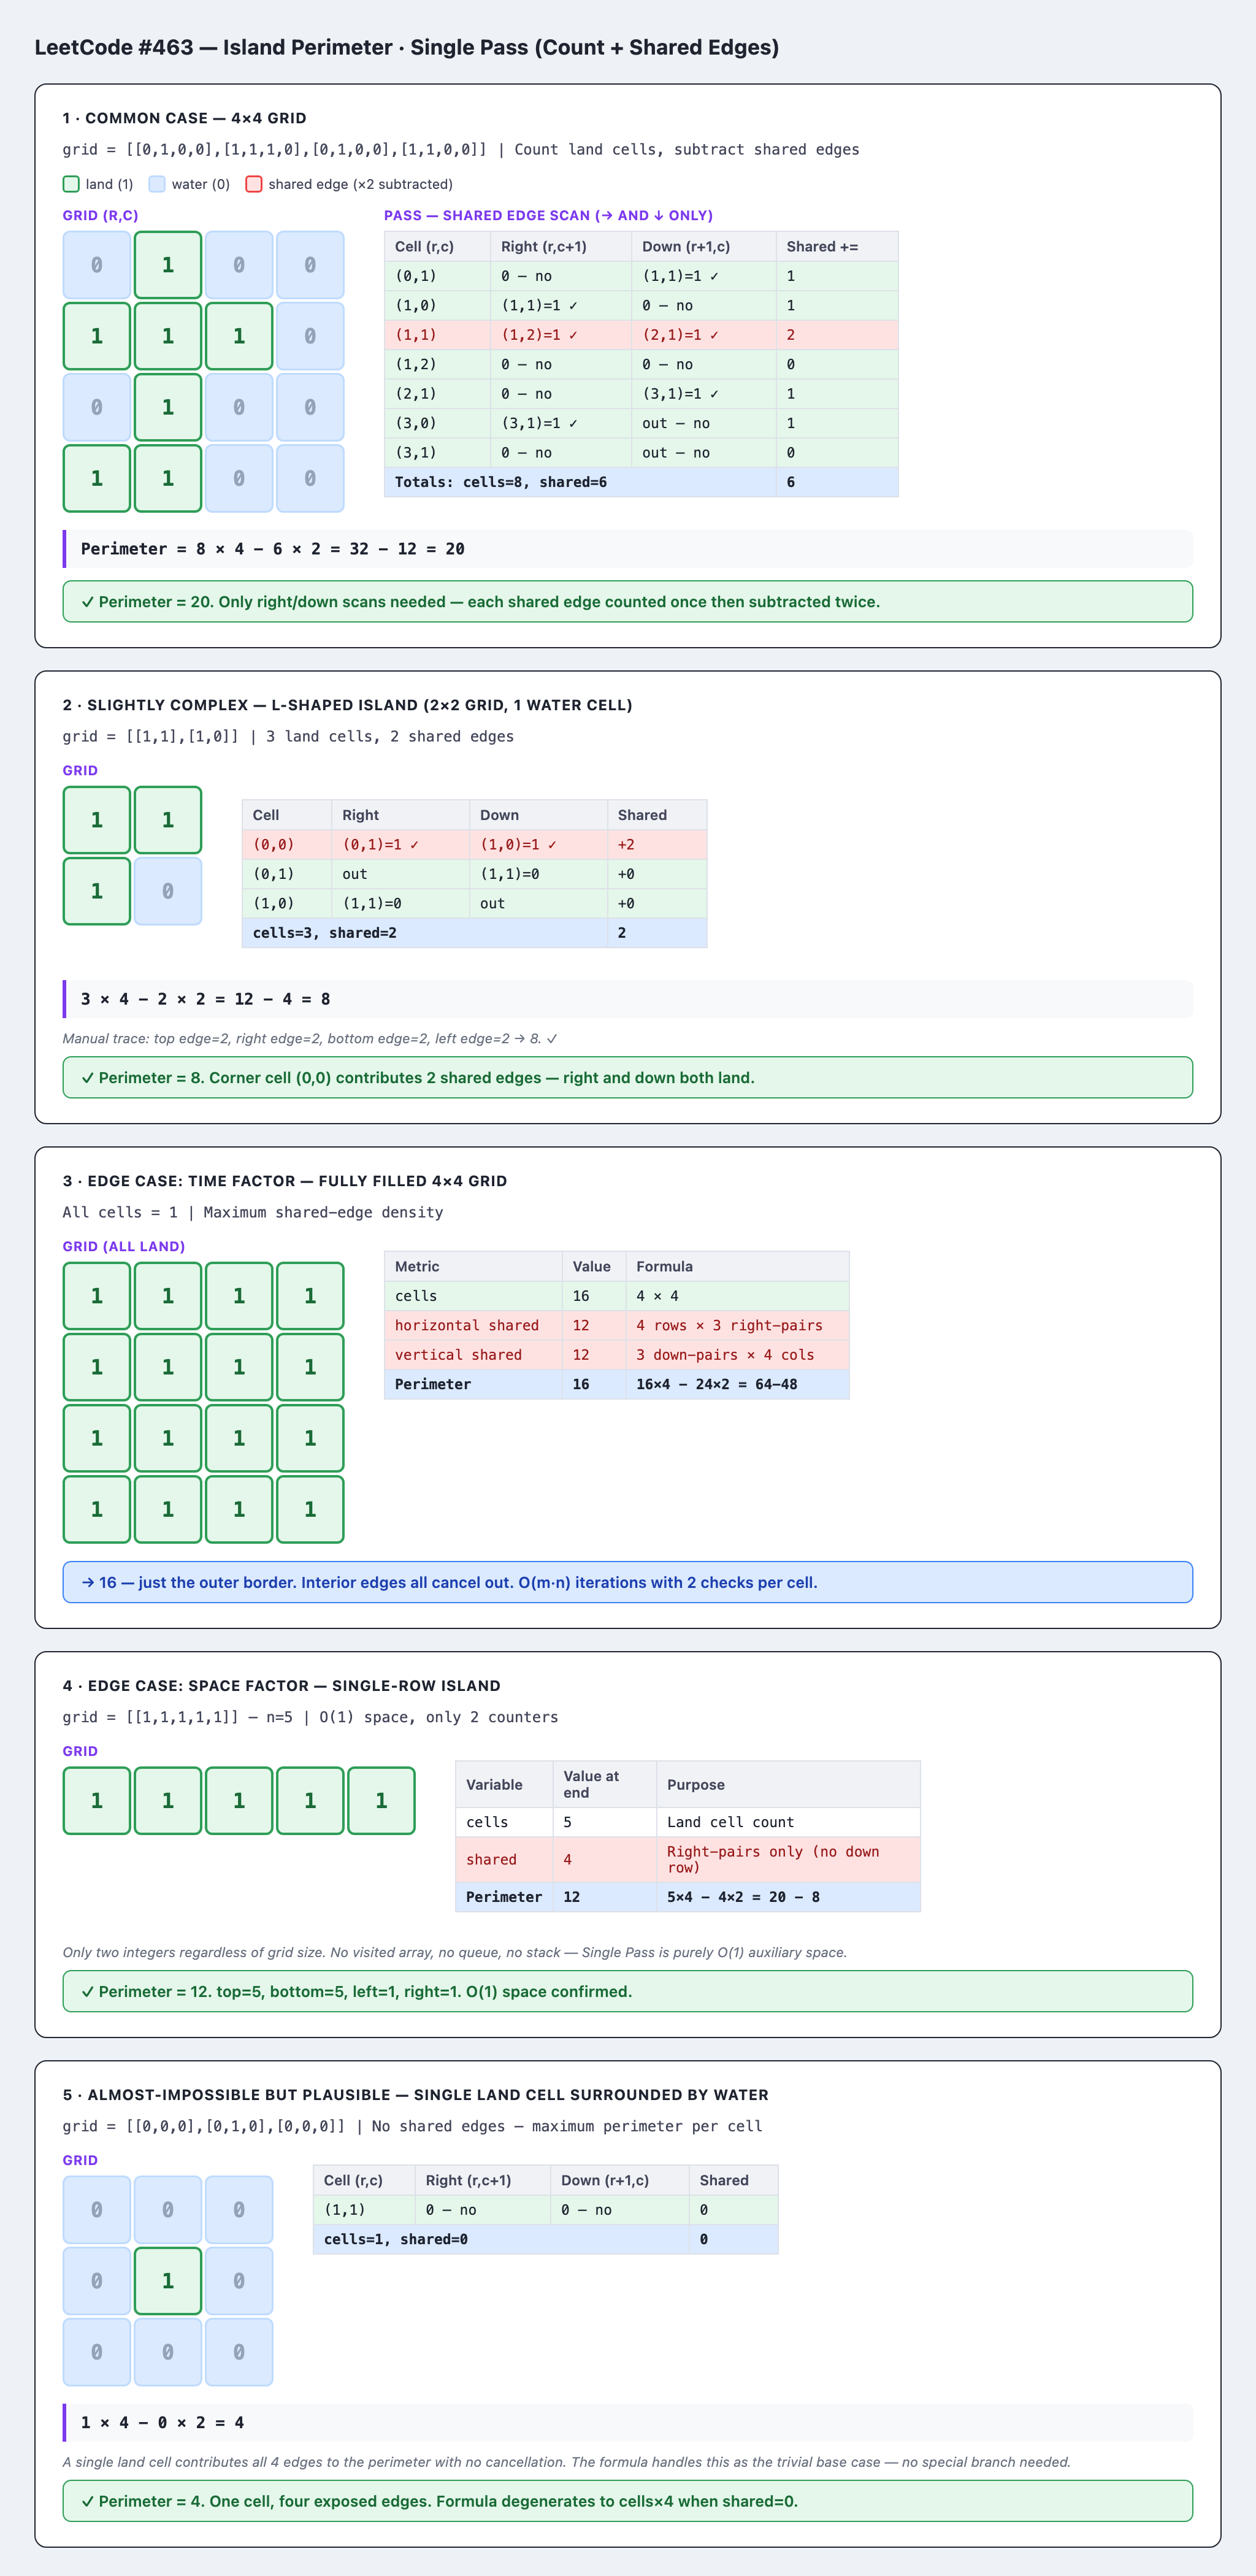